<a href="https://colab.research.google.com/github/bsheese/cs377/blob/main/17_regression_crossval/17_1_SLR/17_1_5_SLR_Transformations.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Simple Linear Regression: Transformations (Bending the Line)

Author: Brad Sheese

---

## What This Notebook Is About

In Notebook 17_1_3 we saw the Auto MPG model fail the **L**inearity assumption spectacularly — a straight line through data that's clearly curving, producing a U-shaped residual plot. At the time we said *"transformations will fix this"* and moved on. Time to make good on that promise.

The whole dilemma of fitting lines to curved data can be summarized in one slogan:

> **You can't bend the OLS line — but you *can* bend the data.**

OLS will always produce a straight line. That's non-negotiable; it's what the letter *L* in OLS (*Linear*) actually means. So if a line is genuinely wrong for your data, you have two choices: abandon OLS and use something nonlinear (neural nets, splines, trees), or **rewrite your variables** so that a straight-line model becomes correct.

That second option is what this notebook is about. Variable **transformations** — swapping `x` for `log(x)` or `1/x` or `x²` — keep us in the comfortable world of OLS while letting us capture relationships that curve. It's the single most powerful technique in an applied regression toolkit, and it's disarmingly simple to apply.

Our running example will be one of the most famous curved relationships in all of data science: **GDP per capita vs. life expectancy**, a.k.a. the Gapminder data. It is the reason *everyone* teaches log transformations.

## Setup

We'll use the Gapminder 2007 snapshot — 142 countries, each with a GDP per capita (USD) and an average life expectancy at birth (years).

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import io
import urllib.request

import statsmodels.api as sm

sns.set_style('whitegrid')

# Gapminder (all years) — from plotly's public datasets repo.
url = 'https://raw.githubusercontent.com/plotly/datasets/master/gapminderDataFiveYear.csv'
req = urllib.request.Request(url,
    headers={'User-Agent': 'Mozilla/5.0 (X11; Linux x86_64) AppleWebKit/537.36'})
with urllib.request.urlopen(req) as resp:
    gapminder = pd.read_csv(io.BytesIO(resp.read()))

# Take just the 2007 snapshot — one row per country.
gap = gapminder[gapminder['year'] == 2007].reset_index(drop=True)

print(f'Countries: {len(gap)}')
gap[['country', 'continent', 'gdpPercap', 'lifeExp']].head()

Countries: 142


,country,continent,gdpPercap,lifeExp
0,Afghanistan,Asia,974.580338,43.828
1,Albania,Europe,5937.029526,76.423
2,Algeria,Africa,6223.367465,72.301
3,Angola,Africa,4797.231267,42.731
4,Argentina,Americas,12779.379640,75.320


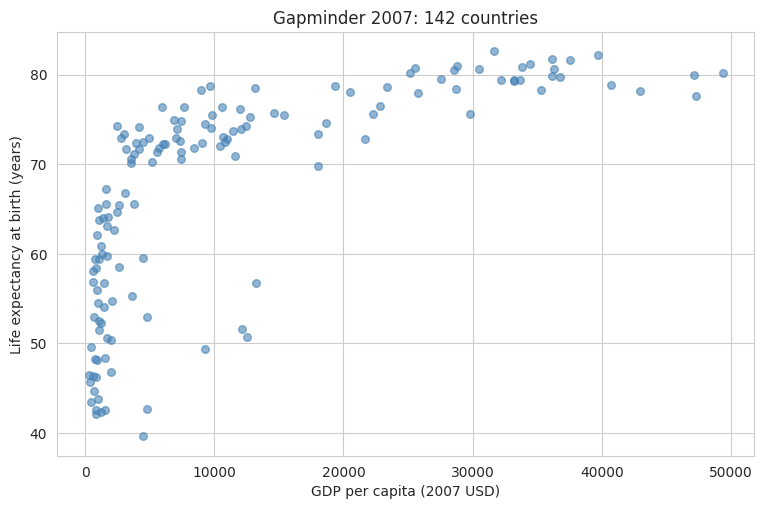

In [2]:
fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(gap['gdpPercap'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue')
ax.set_xlabel('GDP per capita (2007 USD)')
ax.set_ylabel('Life expectancy at birth (years)')
ax.set_title('Gapminder 2007: 142 countries')
plt.show()

There's our textbook logarithmic curve. Three things are immediately obvious:

1. **Richer countries live longer** — the trend is clearly positive.
2. **The returns diminish.** Going from \$500/person to \$5,000/person seems to add roughly 20 years of life expectancy. Going from \$30,000 to \$50,000 adds maybe 1 or 2 years. The effect is *not* proportional to the size of the dollar change.
3. **The scatter is huge** at low GDP — countries with \$500–\$2,000 per capita range from the mid-40s to the late-70s in life expectancy — and much smaller at the right end.

That shape is the LINE diagnostics' worst nightmare: non-linear (U-shape residuals coming) and heteroscedastic (funnel coming). Let's fit a line to it anyway and watch OLS struggle.

---

## Section 1: The Failing Model

Same API call as every other notebook in this series.

In [3]:
x = gap['gdpPercap']
y = gap['lifeExp']

X_sm = sm.add_constant(x)
model_raw = sm.OLS(y, X_sm).fit()

print(f'Slope:      {model_raw.params["gdpPercap"]:.6f} years per $ of GDP/capita')
print(f'Intercept:  {model_raw.params["const"]:.3f} years')
print(f'R^2:        {model_raw.rsquared:.3f}')

Slope:      0.000637 years per $ of GDP/capita
Intercept:  59.566 years
R^2:        0.461


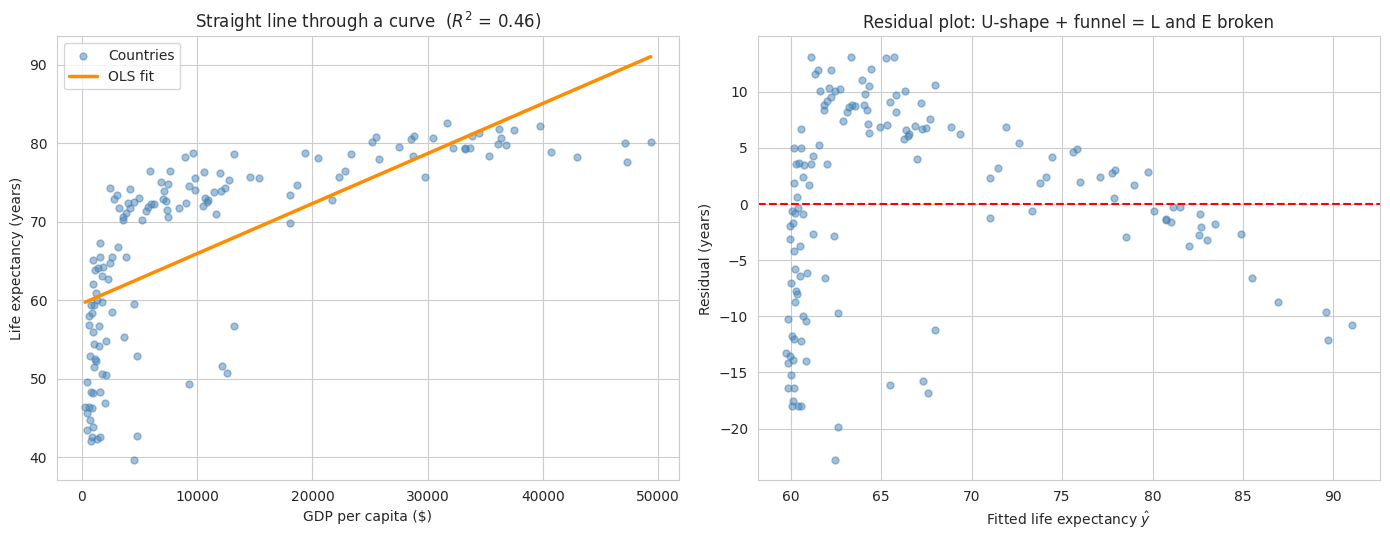

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

# Left: data + fitted line
x_grid = np.linspace(x.min(), x.max(), 200)
axes[0].scatter(x, y, s=25, alpha=0.5, color='steelblue', label='Countries')
axes[0].plot(x_grid, model_raw.predict(sm.add_constant(x_grid)),
             color='darkorange', linewidth=2.5, label='OLS fit')
axes[0].set_xlabel('GDP per capita ($)')
axes[0].set_ylabel('Life expectancy (years)')
axes[0].set_title(f'Straight line through a curve  ($R^2$ = {model_raw.rsquared:.2f})')
axes[0].legend()

# Right: residuals vs fitted
axes[1].scatter(model_raw.fittedvalues, model_raw.resid, s=25, alpha=0.5, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted life expectancy $\\hat{y}$')
axes[1].set_ylabel('Residual (years)')
axes[1].set_title('Residual plot: U-shape + funnel = L and E broken')

plt.tight_layout()
plt.show()

The story told by those two plots:

- **Left:** the line under-predicts life expectancy for poor countries (because it has to slope up from a too-low intercept to catch the rich-country plateau), over-predicts for middle-income countries, and the fit is generally terrible. $R^2 = 0.46$ is unimpressive for a relationship everyone knows is strong.
- **Right:** the residuals spell out a near-perfect curved arc with systematically smaller spread on the right. Linearity fails (U-shape) *and* Equal Variance fails (funnel). Two out of four LINE assumptions, gone.

The inferential machinery from 17_1_2 is now untrustworthy. The standard error and p-value statsmodels prints are wrong in ways we can't predict. And crucially — this is not a bad-row problem (17_1_4 doesn't save us). It's a **bad-shape** problem. A line is the wrong tool.

Unless we change what "line" means.

---

## Section 2: Bend the Data, Not the Line

Here is the trick. Look again at the curved scatterplot. The relationship looks a lot like

$$\text{life\_exp} \approx a + b \cdot \log(\text{gdp})$$

which is not a straight-line equation in `gdp` — but it *is* a straight-line equation in a new variable we're allowed to invent: $\tilde{x} = \log(\text{gdp})$.

So we make a new column `log_gdp`, use *that* as the predictor, and fit OLS in the transformed space. Nothing in OLS has to change. The math, the API, the statistics — all identical. The only thing that changed is *what variable we hand to `.fit()`*.

Let's compute `log_gdp` and look at it.

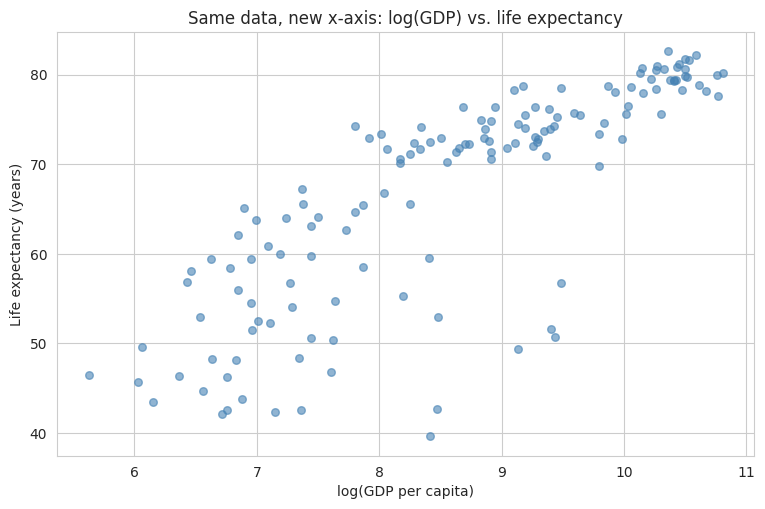

In [5]:
gap['log_gdp'] = np.log(gap['gdpPercap'])

fig, ax = plt.subplots(figsize=(9, 5.5))
ax.scatter(gap['log_gdp'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue')
ax.set_xlabel('log(GDP per capita)')
ax.set_ylabel('Life expectancy (years)')
ax.set_title('Same data, new x-axis: log(GDP) vs. life expectancy')
plt.show()

**That is a straight line.** The exact same 142 countries, the exact same life expectancies — we didn't add or remove any data. All we did was replace the x-axis with its logarithm, and the curve straightened out.

Now we fit OLS on the transformed variable and see what the diagnostics look like.

In [6]:
X_log = sm.add_constant(gap['log_gdp'])
model_log = sm.OLS(gap['lifeExp'], X_log).fit()

print(f'Slope (on log GDP):  {model_log.params["log_gdp"]:.3f} years per log-unit of GDP')
print(f'Intercept:           {model_log.params["const"]:.2f} years')
print(f'R^2:                 {model_log.rsquared:.3f}')
print(f'                     (up from {model_raw.rsquared:.3f} on raw GDP)')

Slope (on log GDP):  7.203 years per log-unit of GDP
Intercept:           4.95 years
R^2:                 0.654
                     (up from 0.461 on raw GDP)


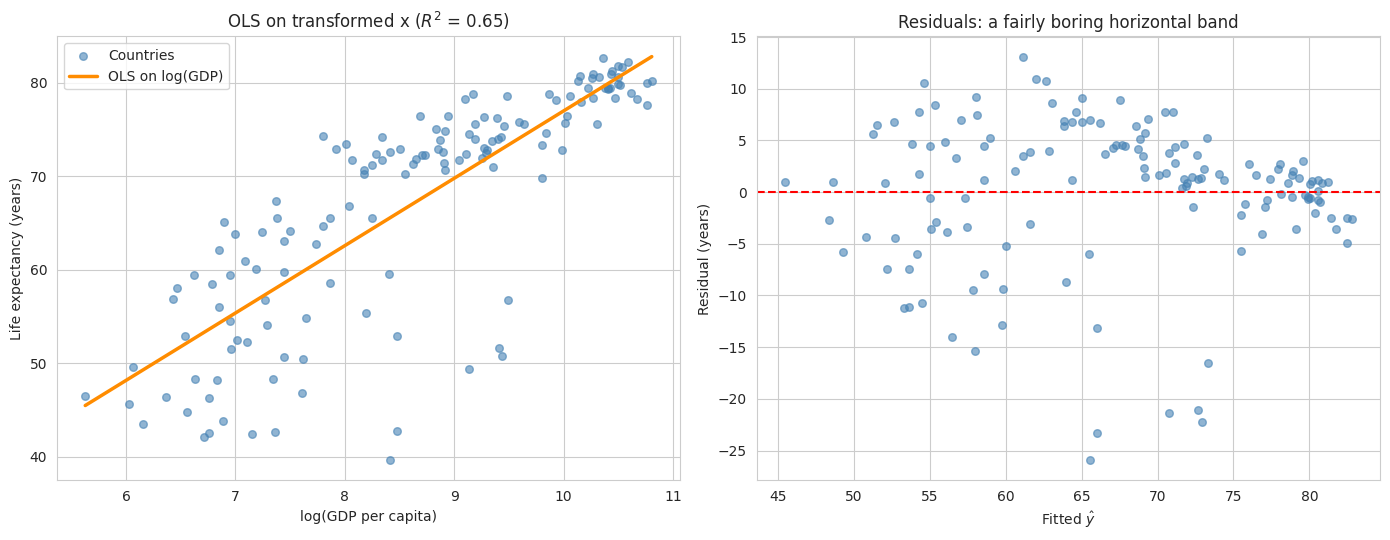

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))

x_log_grid = np.linspace(gap['log_gdp'].min(), gap['log_gdp'].max(), 200)
axes[0].scatter(gap['log_gdp'], gap['lifeExp'], s=30, alpha=0.6, color='steelblue',
                label='Countries')
axes[0].plot(x_log_grid, model_log.predict(sm.add_constant(x_log_grid)),
             color='darkorange', linewidth=2.5, label='OLS on log(GDP)')
axes[0].set_xlabel('log(GDP per capita)')
axes[0].set_ylabel('Life expectancy (years)')
axes[0].set_title(f'OLS on transformed x ($R^2$ = {model_log.rsquared:.2f})')
axes[0].legend()

axes[1].scatter(model_log.fittedvalues, model_log.resid, s=30, alpha=0.6, color='steelblue')
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_xlabel('Fitted $\\hat{y}$')
axes[1].set_ylabel('Residual (years)')
axes[1].set_title('Residuals: a fairly boring horizontal band')

plt.tight_layout()
plt.show()

Compare this pair of plots to the pair in Section 1:

- The fitted line now hugs the data all the way from poor countries to rich ones.
- $R^2$ jumped from **0.46 to 0.65**.
- The residuals are now a patternless cloud — no U, no funnel. Linearity and equal variance are (mostly) restored.

> **This is the entire point of this notebook.** We didn't touch OLS. We didn't touch statsmodels. We added one column to the dataframe. Everything downstream of the fit — the slope, the $R^2$, the standard errors, the p-values, the confidence intervals — is now trustworthy again, because the assumptions they depend on are no longer badly violated.

But now we have a new problem: **the slope of this new regression is 7.2 *years per log-unit of GDP*.** What on Earth does that mean? A one-log-unit increase in GDP isn't something anyone thinks about. Section 3 is how you translate that into English.

---

## Section 3: Interpreting a Log-Linear Slope

### The math in one line

If our model is

$$y = \beta_0 + \beta_1 \log(x)$$

then taking the derivative with respect to $x$ gives

$$\frac{dy}{dx} = \beta_1 \cdot \frac{1}{x} \qquad \Longleftrightarrow \qquad dy = \beta_1 \cdot \frac{dx}{x}$$

The fraction $dx/x$ is a *proportional change* in $x$ — it's how economists define a percent change. So the magic interpretation of a log-x regression is:

> **A 1% increase in $x$ is associated with a $\beta_1 / 100$ unit change in $y$.**

For our Gapminder fit, $\beta_1 \approx 7.2$ years per log-unit, which means a 1% increase in GDP per capita is associated with **0.072 years (≈ 26 days) more life expectancy.**

That's an interpretation that actually says something about the world. Which 1% increase? The *same* 1% increase everywhere on the scale — going from \$1,000 to \$1,010 and going from \$50,000 to \$50,500 both buy you 30 days of life expectancy, on average. *That* is what the log transformation encodes: **equal percentage changes, not equal dollar changes, are the unit of interest.**

Let's verify this on the actual fit.

In [8]:
beta = model_log.params['log_gdp']

print(f'Slope (beta_1):                {beta:.4f} years per log-unit')
print()
print('Interpretations:')
print(f'  +1% in GDP  -> +{beta / 100:.4f} years ({beta / 100 * 365:.1f} days) of life expectancy')
print(f'  +10% in GDP -> +{beta * np.log(1.10):.3f} years')
print(f'  +50% in GDP -> +{beta * np.log(1.50):.3f} years')
print(f'  Doubling    -> +{beta * np.log(2):.3f} years    (log(2) = 0.693)')
print(f'  10x GDP     -> +{beta * np.log(10):.2f} years   (log(10) = 2.303)')

Slope (beta_1):                7.2028 years per log-unit

Interpretations:
  +1% in GDP  -> +0.0720 years (26.3 days) of life expectancy
  +10% in GDP -> +0.687 years
  +50% in GDP -> +2.920 years
  Doubling    -> +4.993 years    (log(2) = 0.693)
  10x GDP     -> +16.59 years   (log(10) = 2.303)


Those numbers actually match the real world. Doubling a country's GDP per capita is associated with about 5 extra years of life expectancy. A 10× increase — the gap between, say, sub-Saharan Africa and Western Europe — is associated with about 17 years. These are the right order of magnitude for what development economists observe.

### The vocabulary: "elasticity"

Economists call this kind of sensitivity — units of $y$ per percent of $x$ — an **elasticity** (technically a "semi-elasticity" since only one side is logged). If you ever talk to an economist about regression, they will reach for log-transformed variables in roughly 90% of models for this exact reason: the coefficients are interpretable as elasticities, which are meaningful across wildly different scales.

### Three flavors of log you'll see in practice

| Model                       | Formula                     | Slope interpretation |
|---                          |---                          |---|
| **Level–level** (plain OLS) | $y = \beta_0 + \beta_1 x$            | +1 unit of $x$ ⇒ +$\beta_1$ units of $y$. |
| **Log–level** (log y only)  | $\log y = \beta_0 + \beta_1 x$       | +1 unit of $x$ ⇒ +$100 \beta_1$ % in $y$. |
| **Level–log** (log x only)  | $y = \beta_0 + \beta_1 \log x$       | +1% in $x$ ⇒ +$\beta_1/100$ units of $y$. *(Our Gapminder fit.)* |
| **Log–log** (both logged)   | $\log y = \beta_0 + \beta_1 \log x$  | +1% in $x$ ⇒ +$\beta_1$% in $y$. *(Pure elasticity.)* |

The log–log is especially elegant: the slope is just *"percent per percent,"* a pure dimensionless elasticity that has no units and doesn't care whether you measure $x$ in dollars, euros, or gold doubloons.

---

## Section 4: The Transformation Toolkit

`log` is the transformation you'll use 80% of the time, but it isn't the only tool. Here's the full kit and when to reach for each one:

| Transformation | Fixes what? | Use when the scatter looks like… |
|---|---|---|
| $\log(x)$ | curve + funnel in *x* | Diminishing returns; $x$ spans several orders of magnitude. |
| $\log(y)$ | curve + funnel in *y* | $y$ spans several orders of magnitude; spread grows with the mean. |
| $\log(y)$ *and* $\log(x)$ | both | Power laws — straight line on a log-log plot. |
| $1/x$ (reciprocal) | asymptotic decay | $y$ approaches a floor as $x$ grows (e.g. MPG vs. engine size). |
| $\sqrt{x}$ | mild curvature | Gentle concavity; less aggressive than log. |
| $x^2$, $x^3$ (polynomial terms) | turning points | True U-shaped or hump-shaped relationships. |
| **Box-Cox** | finds its own $\lambda$ | When you want a machine to pick the best power transformation for $y$. |

Two rules of thumb:

1. **Try the transformation that physics/economics suggests first.** MPG × displacement is roughly a physical constant, so `1/displacement` is the motivated choice. GDP effects compound proportionally, so `log(GDP)` is the motivated choice.
2. **The best transformation makes the residual plot look boring.** That's the whole test. Boring residual plot = transformation worked. Curve, funnel, or bump = keep trying.

---

## Section 5: Promise Kept — Fixing the MPG Model from 17_1_3

Back in Notebook 17_1_3 we fit `mpg = a + b · displacement` and got a beautiful U-shaped residual plot — the textbook failure of linearity. We promised we'd come back and fix it here. Let's.

The physics suggests the fix. Fuel efficiency (miles *per* gallon) and engine size are inversely related — a bigger engine burns more fuel per mile, so `1/mpg` (gallons per mile) should be roughly linear in `displacement`. Flipping that around, that means `mpg` itself should be roughly linear in `1/displacement`. So let's transform $x$ with a reciprocal instead of a logarithm.

In [9]:
mpg = sns.load_dataset('mpg').dropna().reset_index(drop=True)

# Raw model (from 17_1_3)
X_raw = sm.add_constant(mpg['displacement'])
mpg_raw = sm.OLS(mpg['mpg'], X_raw).fit()

# Transformed model
mpg['inv_disp'] = 1.0 / mpg['displacement']
X_inv = sm.add_constant(mpg['inv_disp'])
mpg_inv = sm.OLS(mpg['mpg'], X_inv).fit()

print(f'Raw model:           mpg = a + b * displacement,     R^2 = {mpg_raw.rsquared:.3f}')
print(f'Transformed model:   mpg = a + b / displacement,     R^2 = {mpg_inv.rsquared:.3f}')

Raw model:           mpg = a + b * displacement,     R^2 = 0.648
Transformed model:   mpg = a + b / displacement,     R^2 = 0.661


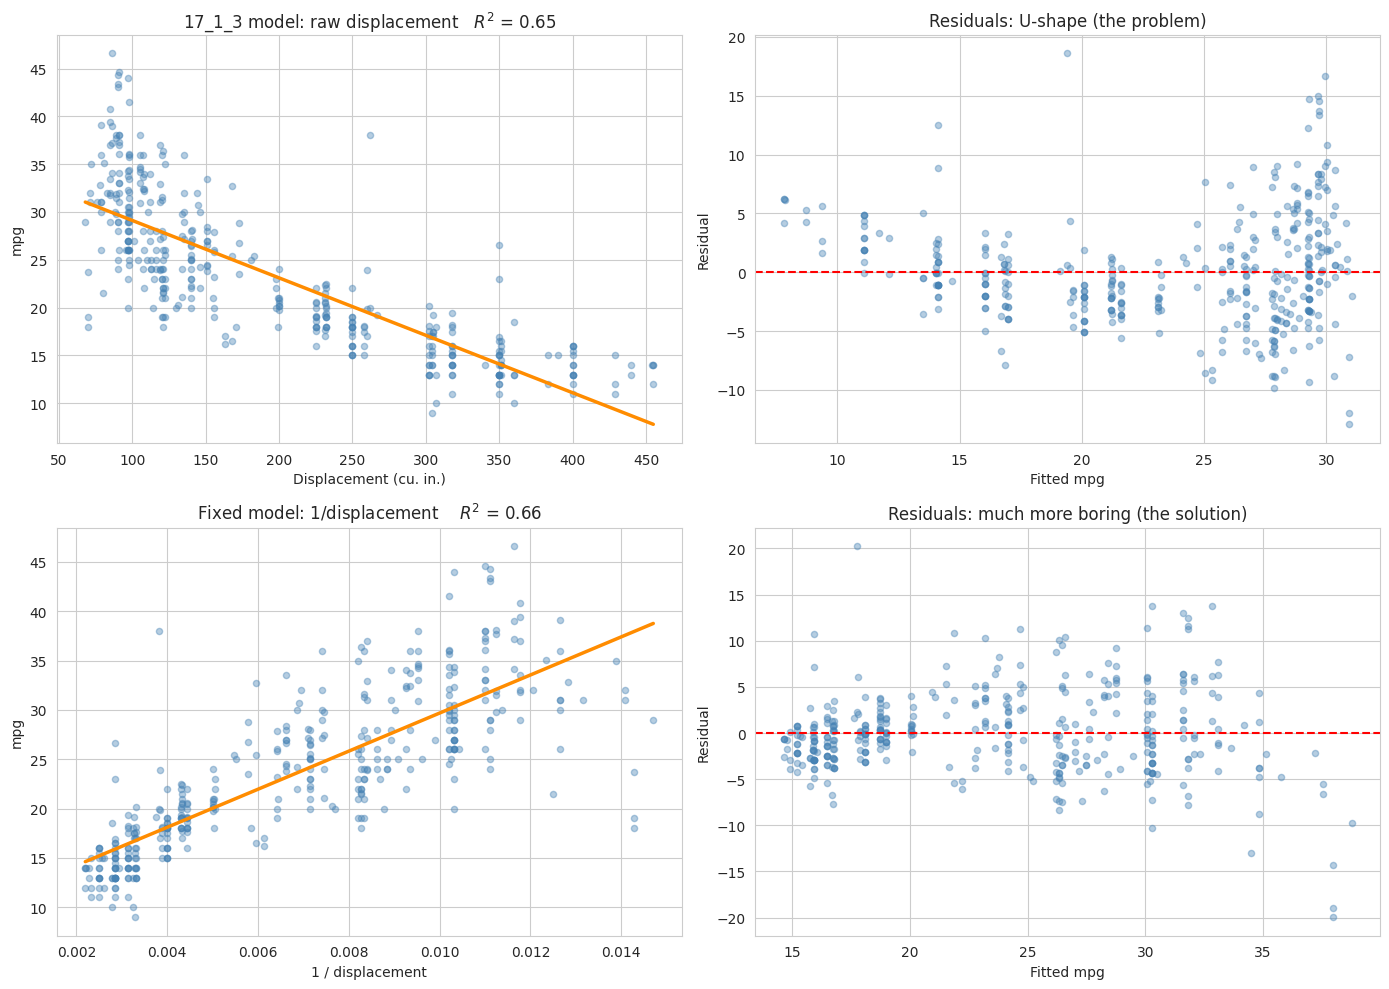

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Top row: raw model — same plots we saw in 17_1_3.
disp_grid = np.linspace(mpg['displacement'].min(), mpg['displacement'].max(), 200)
axes[0, 0].scatter(mpg['displacement'], mpg['mpg'], s=20, alpha=0.4, color='steelblue')
axes[0, 0].plot(disp_grid, mpg_raw.predict(sm.add_constant(disp_grid)),
                color='darkorange', linewidth=2.5)
axes[0, 0].set_xlabel('Displacement (cu. in.)')
axes[0, 0].set_ylabel('mpg')
axes[0, 0].set_title(f'17_1_3 model: raw displacement   $R^2$ = {mpg_raw.rsquared:.2f}')

axes[0, 1].scatter(mpg_raw.fittedvalues, mpg_raw.resid, s=20, alpha=0.4, color='steelblue')
axes[0, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[0, 1].set_xlabel('Fitted mpg')
axes[0, 1].set_ylabel('Residual')
axes[0, 1].set_title('Residuals: U-shape (the problem)')

# Bottom row: transformed model.
inv_grid = np.linspace(mpg['inv_disp'].min(), mpg['inv_disp'].max(), 200)
axes[1, 0].scatter(mpg['inv_disp'], mpg['mpg'], s=20, alpha=0.4, color='steelblue')
axes[1, 0].plot(inv_grid, mpg_inv.predict(sm.add_constant(inv_grid)),
                color='darkorange', linewidth=2.5)
axes[1, 0].set_xlabel('1 / displacement')
axes[1, 0].set_ylabel('mpg')
axes[1, 0].set_title(f'Fixed model: 1/displacement    $R^2$ = {mpg_inv.rsquared:.2f}')

axes[1, 1].scatter(mpg_inv.fittedvalues, mpg_inv.resid, s=20, alpha=0.4, color='steelblue')
axes[1, 1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1, 1].set_xlabel('Fitted mpg')
axes[1, 1].set_ylabel('Residual')
axes[1, 1].set_title('Residuals: much more boring (the solution)')

plt.tight_layout()
plt.show()

Top row is the broken model from 17_1_3. Bottom row is the fixed one. Same dataset, same OLS, same 392 cars — just a different variable fed to `.fit()`. $R^2$ climbed modestly (from 0.65 to 0.66), but look at the bottom-right residual plot: **the U-shape has essentially vanished.** That's the real payoff. Once the residuals are patternless, all the inferential statistics from 17_1_2 — the `std err`, the p-value, the confidence interval — become trustworthy again, which they weren't for the raw model.

> **The right metric for a successful transformation is the residual plot, not the $R^2$.** A transformation that bumps $R^2$ by 0.01 *and* removes a major residual pattern is a much bigger win than a transformation that bumps $R^2$ by 0.05 but leaves the residuals curved.

Is it perfect? No — there's still some mild heteroscedasticity, and a log transformation on displacement might have squeezed out another percentage point or two of $R^2$. But as a fix that took one line of code and one physics-motivated substitution, it delivered exactly what it promised: a model whose residuals look like random noise.

---

## A Few Honest Warnings

Transformations are powerful, but they change what your model *says*. Read these before you go nuts with `np.log` on everything:

1. **The slope's meaning changes.** After a log transformation the slope is an elasticity, not a dollar-per-dollar effect. Always report the transformation and spell out the interpretation in plain English for your reader.
2. **You can't log (or square-root) non-positive values.** GDP and body mass are positive, so we're fine. Temperatures, profits, or residuals may not be. Reach for `np.log1p(x)` (which computes $\log(1+x)$) when $x$ can legitimately be zero.
3. **Predictions have to be back-transformed.** If you modeled $\log y$ and want a prediction in $y$-units, you need to exponentiate (and there's a small *Jensen's-inequality* bias correction serious statisticians care about). We won't dwell on this — just be aware.
4. **A transformation that hides a problem isn't the same as one that solves it.** The test is always the residual plot. If residuals still show a pattern after transformation, the transformation didn't work and you need a different one (or a fundamentally different model).
5. **The $R^2$ values of models on different-scale $y$'s are not directly comparable.** If one model has $y$ = mpg and another has $y$ = log(mpg), their $R^2$ values are measuring variance on different scales. Compare residual patterns, not raw $R^2$s.

---

## Putting It All Together

Here is the entire transformation workflow in one place:

> **Fit OLS → check residuals → if they show a pattern, transform → refit → recheck → interpret carefully.**

And the core slogan:

> **You can't bend the line, but you can bend the data.** Every nonlinear relationship that's *monotonic* and *smooth* has some transformation that straightens it.

Two concrete demonstrations in one notebook:

| Dataset | Raw model $R^2$ | Transformation | Transformed $R^2$ | Residual pattern after transform |
|---|---:|---|---:|---|
| Gapminder (GDP → life exp) | 0.46 | $\log$(GDP) | 0.65 | Patternless cloud |
| Auto MPG (displacement → mpg) | 0.65 | $1/$displacement | 0.66 | U-shape fixed; mild heteroscedasticity remains |

Both times, adding one column to the dataframe improved the fit, fixed a LINE violation, and gave us a slope with a physically meaningful interpretation — even when (as with MPG) the $R^2$ barely moved.

### Where We're Going Next

We've now spent five notebooks fitting the best possible line to the data in front of us — checking significance, checking assumptions, hunting bad rows, transforming variables. Every one of those operations has been about *the data we already have*.

But the whole reason we fit models in the first place is to say something about **data we haven't seen yet**. A model that fits our current 333 penguins or 142 countries perfectly could still make terrible predictions on *future* penguins or *other* countries.

In `17_1_6_SLR_GeneralizationTest.ipynb` we'll finally confront this head-on with **train/test splits** — the universal discipline of machine learning. It's how we go from "my model fits this data" to "my model generalizes."